In [269]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

import matplotlib.pyplot as plt
import seaborn as sns

### Simule um conjunto de dados com um preditor e uma relação linear acrescida de ruído Gaussiano


In [270]:
np.random.seed(42)

X = np.linspace(0,10,50)

Y_limpo = 2 * X + 5
ruido = np.random.normal(loc=0.0, scale=5, size=X.shape)
Y = Y_limpo + ruido

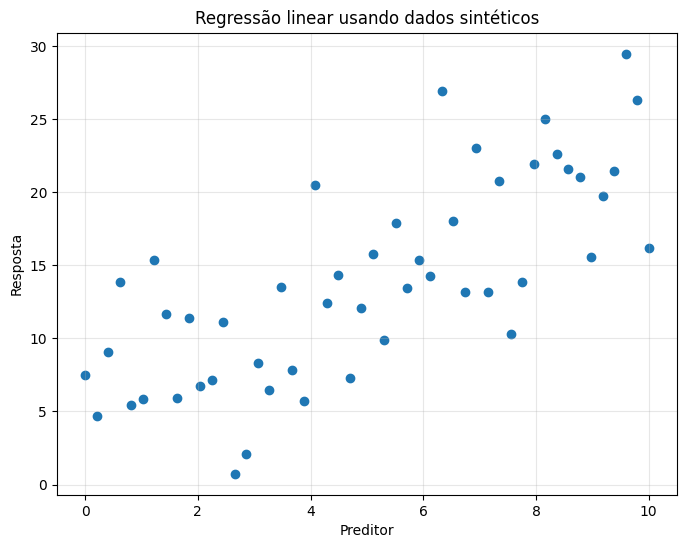

In [271]:
plt.figure(figsize=(8,6))

plt.scatter(X, Y)
plt.title("Regressão linear usando dados sintéticos")
plt.xlabel("Preditor")
plt.ylabel("Resposta")
plt.grid(True, alpha=0.3)

plt.show()

### Ajuste um modelo de regressão linear e plote os dados junto com a linha de regressão.

#### Aplicando a fórmula fechada da OLS -> $((X^{T}.X)^{-1}).X^T.y$

In [272]:
X_b = np.c_[np.ones((len(X), 1)), X] # Primeira coluna de uns
print(X_b)

[[ 1.          0.        ]
 [ 1.          0.20408163]
 [ 1.          0.40816327]
 [ 1.          0.6122449 ]
 [ 1.          0.81632653]
 [ 1.          1.02040816]
 [ 1.          1.2244898 ]
 [ 1.          1.42857143]
 [ 1.          1.63265306]
 [ 1.          1.83673469]
 [ 1.          2.04081633]
 [ 1.          2.24489796]
 [ 1.          2.44897959]
 [ 1.          2.65306122]
 [ 1.          2.85714286]
 [ 1.          3.06122449]
 [ 1.          3.26530612]
 [ 1.          3.46938776]
 [ 1.          3.67346939]
 [ 1.          3.87755102]
 [ 1.          4.08163265]
 [ 1.          4.28571429]
 [ 1.          4.48979592]
 [ 1.          4.69387755]
 [ 1.          4.89795918]
 [ 1.          5.10204082]
 [ 1.          5.30612245]
 [ 1.          5.51020408]
 [ 1.          5.71428571]
 [ 1.          5.91836735]
 [ 1.          6.12244898]
 [ 1.          6.32653061]
 [ 1.          6.53061224]
 [ 1.          6.73469388]
 [ 1.          6.93877551]
 [ 1.          7.14285714]
 [ 1.          7.34693878]
 

$((X^{T}.X)^{-1}).X^T.y$

In [273]:
theta = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ Y
print(f"Intercepto: {theta[0]}")
print(f"Inclinação: {theta[1]}")

Intercepto: 5.322215461014861
Inclinação: 1.7100830025408866


In [274]:
prediction_formula = X_b @ theta

In [275]:
# Usando o Scikit-Learn

X_R = X.reshape(-1, 1)

lr = LinearRegression()
lr.fit(X_R, Y)

LinearRegression()

In [276]:
prediction_scikit = lr.predict(X_R)

In [277]:
print(f"Intercepto: {lr.intercept_}")
print(f"Inclinação: {lr.coef_[0]}")

Intercepto: 5.32221546101486
Inclinação: 1.7100830025408875


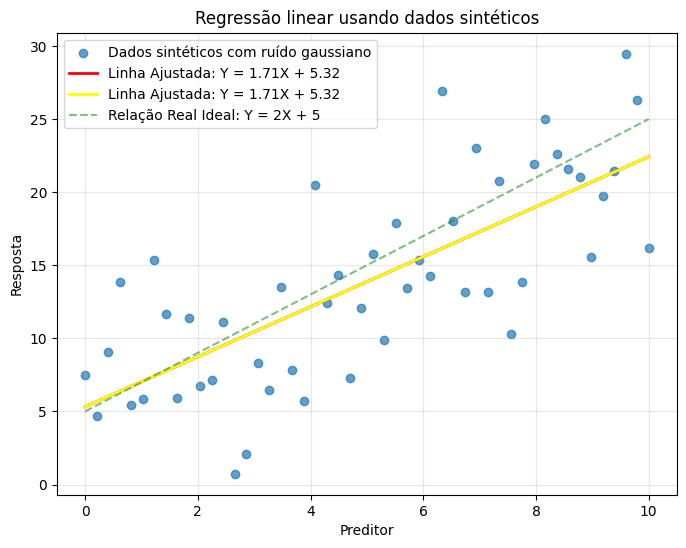

In [278]:
plt.figure(figsize=(8,6))

plt.scatter(X, Y, alpha=0.7, label="Dados sintéticos com ruído gaussiano")
plt.title("Regressão linear usando dados sintéticos")
plt.xlabel("Preditor")
plt.ylabel("Resposta")
plt.grid(True, alpha=0.3)
plt.plot(X, prediction_formula, color='red', linewidth=2, label=f'Linha Ajustada: Y = {theta[1]:.2f}X + {theta[0]:.2f}')
plt.plot(X, prediction_scikit, color='yellow', linewidth=2, label=f'Linha Ajustada: Y = {lr.coef_[0]:.2f}X + {lr.intercept_:.2f}')
plt.plot(X, Y_limpo, color='green', linestyle='--', alpha=0.5, label='Relação Real Ideal: Y = 2X + 5')
plt.legend()

plt.show()

### Comparação de performances

In [279]:
from sklearn.metrics import r2_score, mean_squared_error

comparacao = pd.DataFrame({
    "Modelo": ["LR-Fórmula", "LR-Scikit"],
    "R² Score": [r2_score(Y_limpo, prediction_formula), r2_score(Y_limpo, prediction_scikit)],
    "MSE": [mean_squared_error(Y_limpo, prediction_formula), mean_squared_error(Y_limpo, prediction_scikit)]
})

print(comparacao.to_string(index=False))

    Modelo  R² Score      MSE
LR-Fórmula  0.942353 1.999983
 LR-Scikit  0.942353 1.999983
